
# Lab 3: PDE with FDM

#Exercise 1

In [33]:
import numpy as np
import matplotlib.pyplot as plt


vo, iter = 100, 1020
def Laplace2D_FDM(V_ini,tolerancia):
  'Int the V initial configutaration.\n Niter is the number of the iterations of the algorithm. Return V_out Laplace case.'

  Nmax = V_ini.shape[0]
  V1 = V_ini.copy()
  tol = 1
  termi = 1
  while tol >= tolerancia:
    V2 = V1.copy()

    for i in range(1, Nmax-1):
      for j in range(1,Nmax-1):
        V1[i,j] = 0.25*(V2[i+1,j]+V2[i-1,j]+V2[i,j+1]+V2[i,j-1])
    tol = np.max(np.abs(V2-V1))
    termi +=1
  return V1, termi
condiciones = np.zeros((100,100),float)
for i in range(vo):
  condiciones[i,0] = 100

solu = Laplace2D_FDM(condiciones,10**(-4))


La estrategia que use para diferencias finitras fue aplicar el codigo del profe de diferencias finitas con unas ciertas modificaciones para que toda la matriz re escribiera antes de volver a usar los valores hallados en un paso, y luego la tolerancia fue hecha buscando que el valor mas alto de la diferencia de la matriz anterior con la nueva cumpliera la tolerancia minima esperada. Otro metodo hubiera sido que cada valor que se obtuviera de la matriz nueva se revisara en el mismo for si cumplia la tolerancia al hacer la diferencia.

In [36]:
def un(x,y,n=1,L=1):
  'function to compute the n-esimo term of the Fouriers serie'
  v0 = 100
  return (4*v0/(n*np.pi))*np.sin(n*np.pi*x/L)*np.sinh(n*np.pi*(L-y)/L)/np.sinh(n*np.pi)

L = 100
N1 = 100

x1 = np.linspace(0, L, N1)
y1 = x1
X1, Y1 = np.meshgrid(x1, y1, indexing="ij")
z = np.zeros_like(X1)
tol = 1
n= 1
z6 = z.copy()
termi = 1
while tol >= 10**(-4):
  prueba = un(X1, Y1, n, L)
  z += un(X1, Y1, n, L)
  n += 2
  termi+= 1
  tol = np.max(np.abs(prueba))
print("terminos necesarios para que la sumatoria obtenga una tolerancia de 10^(-4):", termi)
print("terminos necesarios para que las diferencias finitas obten la tolerancia de 10^(-4):", solu[1])

terminos necesarios para que la sumatoria obtenga una tolerancia de 10^(-4): 51
terminos necesarios para que las diferencias finitas obten la tolerancia de 10^(-4): 10563


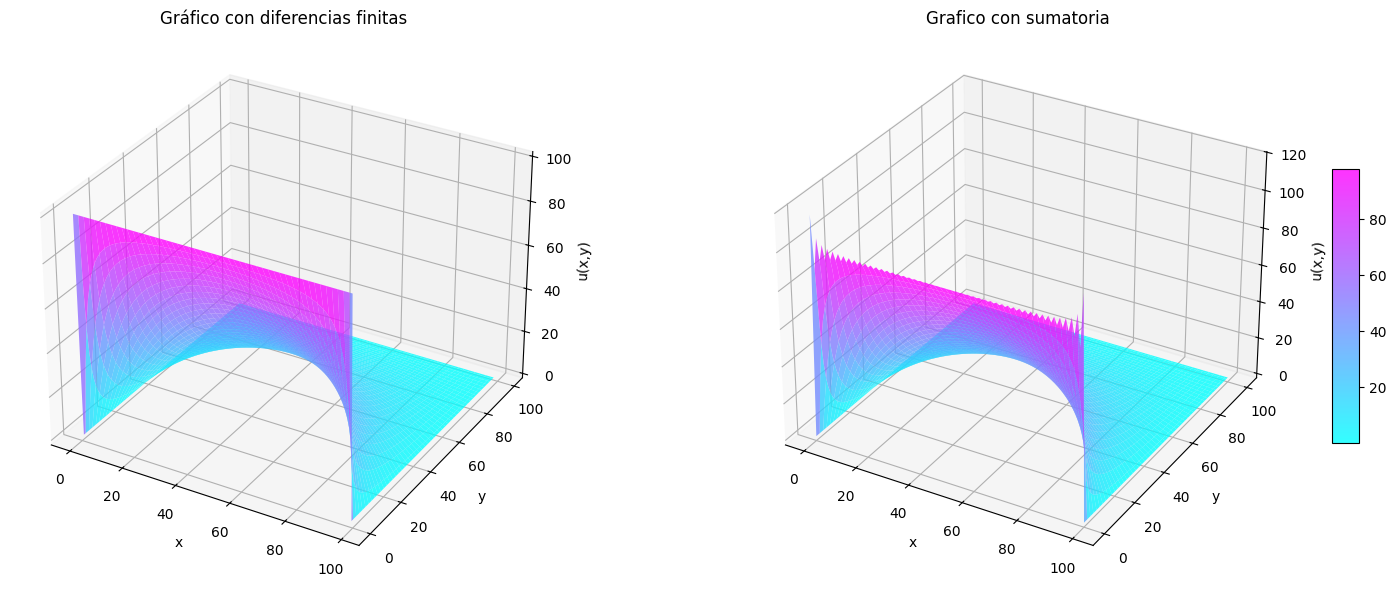

In [35]:
x = np.arange(100)
y = x
X, Y = np.meshgrid(x, y, indexing="ij")

z1 = solu[0][X, Y]
fig = plt.figure(figsize=(16, 6))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X, Y, z1, cmap='cool', alpha=0.8)
ax1.set_title('Gráfico con diferencias finitas')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('u(x,y)')
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf = ax2.plot_surface(X1, Y1, z, cmap='cool', alpha=0.8, edgecolor='none')
ax2.set_title('Grafico con sumatoria')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel('u(x,y)')

fig.colorbar(surf, ax=ax2, shrink=0.5, aspect=10)

plt.tight_layout()
plt.show()

#Punto 3

In [92]:
def Laplace2D_capa(V_ini,tolerancia,pos_cap1,pos_cap2):
  'Int the V initial configutaration.\n Niter is the number of the iterations of the algorithm. Return V_out Laplace case.'

  Nmax = V_ini.shape[0]
  V1 = V_ini.copy()
  tol = 1
  termi = 1
  while tol >= tolerancia:
    V2 = V1.copy()

    for i in range(1, Nmax-1):
      if i != pos_cap1 and i!= pos_cap2:
        for j in range(1,Nmax-1):
          V1[i,j] = 0.25*(V2[i+1,j]+V2[i-1,j]+V2[i,j+1]+V2[i,j-1])
    tol = np.max(np.abs(V2-V1))
    termi +=1
  return V1, termi

In [93]:
vo = 100
pos1 = 39
pos2 = 69
capacitor1 = np.zeros((100,100),float)
for j in range(20,80):
  capacitor1[pos1][j] = vo
  capacitor1[pos2][j] = -vo

cap = Laplace2D_capa(capacitor1,10**(-4),pos1,pos2)

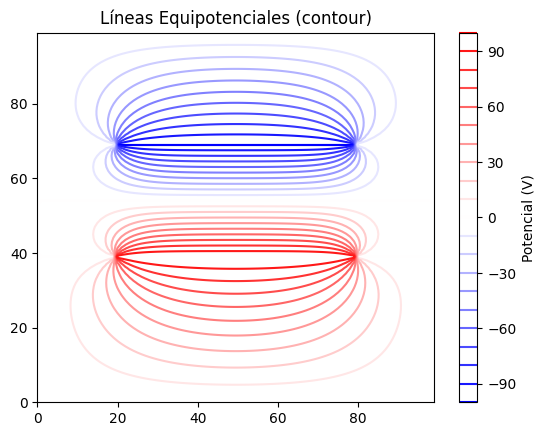

In [94]:
plt.contour(cap[0], levels=20, cmap='bwr')
plt.colorbar(label='Potencial (V)')
plt.title('Líneas Equipotenciales de un capacitor')
plt.show()

#### **Exercise 1**: Finite-differences method (FDM) with tolerance **Jacobi method**.


Laplace's equation in the dominio $0\leq x \leq L$ and $0\leq y \leq L$ with Dirichlet's boundary conditions:

* $u(x,0)=V(x)=f(x)\to V_0=100$ V
* $u(0,y)=0$
* $u(L,y)=0$
* $u(x,L)=0$

1. Solve the Laplace's equation using finite differences for an specific tolerance ($10^{-6}<\text{tol}<10^{-1}$). Do a plot of the field $u(x,y)$ for $\text{tol}=10^{-3}$. Explain in your own words the strategy followed.
2. Compare with the **Fourier serie**. How many terms in the Fourier serie are necessary to get a $\text{tol}=10^{-4}$?

#### **Exercise 2**: FDM for oppen boundaries (bonus!)

1. Solve **analytically** the Laplace's equation for $u(x,y)$ in the dominio $0\leq x \leq L$ and $0\leq y < \infty $, with Dirichlet's boundary conditions:

* $u(x,0)=V(x)=f(x) = u_0\sin(2\pi x/L)e^{-2\pi y/L}$
* $u(0,y)=0$
* $u(L,y)=0$
* $u(x,\infty)=0$,

Explain in your own words the strategy followed and write the analytical result.


1. Solve **numerically** the Laplace's equation, set the lenght $L=N\Delta = 100$ and $\Delta=1$ and $u_0=100$.

<img src="https://github.com/anferivera/Fisica_Computacional_1/raw/main/Sesiones/PDE/figures/Laplace_df_4.png" width="200" height="300" />

## Electric filed and potential in a parallel-plate capacitor

#### **Exercise 3**

To find the potential generated by a capacitor  of two rectangular plates of width $d$ is challenging (see figure). In general, we can do some approximation based in infinite plates to get an intuition of the solution. In this approximation we have:


\begin{equation}
|\vec{E}| \approx \dfrac{\sigma}{2\epsilon_0}, \text{inside}\,,
\end{equation}

\begin{equation}
|\vec{E}| \approx 0, \text{  outside}\,.
\end{equation}


However, we know that the potential $\phi$ and the electric field $\vec{E}$ fulfill the Laplace's equation $\nabla^2\phi = 0$ in the region around the plates (where $\rho=0$).

1. Use finite differences to solve the Laplace's equation in the neigborhood of this capacitor. Use the imshow or the contour function to plot the potential.

2. Compute numerically the electric field (use finite difference method).

<img src="https://github.com/anferivera/Fisica_Computacional_1/raw/main/Sesiones/PDE/figures/Laplace_df_capacitor.png" alt="drawing" width="600"/>